# Science Center Floor Plan Explorer
## Harvard Science Center — Indoor Navigation System

**Course:** CS32 @ Harvard University
**Group Members** Arjun Narasimhan and Leon Katarzynski
**Date:** April 2026

---

### Abstract

This project aims to create a complete indoor navigation system for the Science Center.
Annotated floor plan JSON files — currently covering Floors 1, 2, 3, and 5 — encode every room as a polygon node with typed metadata (classroom, office, corridor, stairwell, elevator, etc.) and a neighbor adjacent list.  A web application (port 5000) uses these files at and runs Dijkstra (so weighted) shortest-path to route users between any two rooms, including across floors via stairwells and elevators.  A labeling server (port 3000) allowed us to hand-trace the outlines of every room of the Science Center. Given that, we first focused on implement a fundamentally working algorithm and did yet not finish categolizing the whole Science Center but enough to run tests.


## 1 · Setup & Data Loading

All floor plan data live in the `Floor Plans/` directory as JSON files.

### Floor Plan JSON Format

Each JSON file contains a single top-level object with a `rooms` array. Every element of `rooms` represents one spatial type a room, corridor, stairwell, door, etc.:

| Field | Type | Description |
|-------|------|-------------|
| `id` | string | Unique identifier within the floor (e.g. `"R322"`, `"stair_north"`) |
| `name` | string | Human-readable label (e.g. `"R322"`, `"Cabot Library"`) |
| `type` | string | One of: `office`, `classroom`, `library`, `lecture`, `stairwell`, `elevator`, `corridor`, `entrance`, `door`, `connection`, `other` |
| `polygon` | `[[x,y],…]` | Ordered list of pixel-coordinate vertices defining the room boundary |
| `labelAnchor` | `{x, y}` | Optional override for the label centroid (used when the polygon centroid is off-centre) |
| `neighbors` | `[id,…]` | IDs of directly adjacent rooms (used to build the navigation graph edges) |
| `connectsFloors` | `[n,…]` | *(stairwells/elevators only)* List of floor numbers this connector reaches |
| `showLabel` | boolean | Whether to render a visible text label on the floor plan canvas |

#### Example room entry

```json
{
  "id": "R322",
  "name": "R322",
  "type": "classroom",
  "polygon": [[412, 210], [530, 210], [530, 290], [412, 290]],
  "labelAnchor": {"x": 471, "y": 250},
  "neighbors": ["corridor_3N", "door_322"],
  "connectsFloors": [],
  "showLabel": true
}
```

### Label visibility logic

- **Classrooms and offices** — shown as `R{number}` (e.g. `R322`, `R114A`)
- **Named spaces** — Cabot Library, Lecture Halls A–D, Courtyard — shown as in complete name
- **Hallways / doors / connections** — `showLabel: false`; labels suppressed
- **Stairwells / elevators** — labels suppressed; rendered with special visual symbols instead

### Floors available

| Floor key | File | Notes |
|-----------|------|-------|
| 1 | `floor1.json` | Ground floor — Cabot Library, Clover, Lecture Halls A–D |
| 2 | `floor2.json` | 2nd floor — offices, classrooms |
| 3 | `floor3.json` | 3rd floor — offices 300s, classrooms |
| 5 | `floor5.json` | 5th floor — research offices 500s |

Floor 4 was not part of the provided floor plans at first. While we received it now, we where not able to update our current data with it yet.


In [19]:
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon as MplPolygon
import numpy as np

# Keys are integers so the statistics pivot table labels floors correctly.
FLOOR_FILES = {
    1: 'Floor Plans/floor1.json',
    2: 'Floor Plans/floor2.json',
    3: 'Floor Plans/floor3.json',
    5: 'Floor Plans/floor5.json',
}

all_floors = {}
for key, path in FLOOR_FILES.items():
    with open(path) as f:
        all_floors[key] = json.load(f)
    print(f'Floor {key}: {len(all_floors[key]["rooms"])} rooms loaded')


Floor 1: 122 rooms loaded
Floor 2: 85 rooms loaded
Floor 3: 148 rooms loaded
Floor 5: 77 rooms loaded


## 2 · Colour Palette & Rendering Engine

The `draw_floor()` function renders each floor plan as a Matplotlib figure. Every room polygon is filled with a color chosen by its `type` field.

### Colour palette

| Type | Hex | Appearance |
|------|-----|------------|
| `office` | `#B5D5E8` | blue |
| `classroom` | `#C8E6C9` | green |
| `library` | `#E8D5B7` | orange |
| `lecture` | `#D7C8E8` | purple |
| `stairwell` | `#ECECEC` | grey + `////` hatch |
| `elevator` | `#FFF9C4` | yellow + × cross |
| `corridor` | `#F0F0F0` | Near-white |
| `entrance` | `#FFD6E0` | rose |
| `other` | `#E0E8D8` | sage |
| `door` / `connection` | `#FFFFFF` | Fully transparent |


In [11]:
PASTEL = {
    'office':     '#B5D5E8',
    'classroom':  '#C8E6C9',
    'library':    '#E8D5B7',
    'lecture':    '#D7C8E8',
    'stairwell':  '#ECECEC',
    'elevator':   '#FFF9C4',
    'corridor':   '#F0F0F0',
    'entrance':   '#FFD6E0',
    'other':      '#E0E8D8',
    'door':       '#FFFFFF',
    'connection': '#FFFFFF',
}
DEFAULT_COLOR = '#F0F0F0'
DOOR_TYPES    = {'door', 'connection'}
LABEL_SIZE    = 5


def draw_floor(floor_data, title):
    """Render a single floor plan from its JSON dict."""
    rooms = floor_data['rooms']

    fig, ax = plt.subplots(figsize=(14, 10))
    fig.patch.set_facecolor('#FAFAFA')

    seen_types = set()  # track which types appear

    for room in rooms:
        pts = room.get('polygon', [])
        if not pts:
            continue

        pts = np.array(pts, dtype=float)
        t       = room.get('type', 'other')
        color   = PASTEL.get(t, DEFAULT_COLOR)
        is_door = t in DOOR_TYPES

        # Stairwells get diagonal hatching instead of a solid fill
        hatch = '////' if t == 'stairwell' else None
        patch = MplPolygon(
            pts, closed=True,
            fc=color,
            ec='#AAAAAA' if is_door else '#888888',
            lw=0.3       if is_door else 0.6,
            alpha=0.0    if is_door else 0.85,   # doors are invisible — they are graph edges, not rooms
            hatch=hatch,
            zorder=1     if is_door else 2,
        )
        ax.add_patch(patch)

        if not is_door:
            seen_types.add(t)

        # Elevator: draw a small × cross
        if t == 'elevator':
            la = room.get('labelAnchor', {})
            cx = la.get('x', pts[:, 0].mean())
            cy = la.get('y', pts[:, 1].mean())
            r  = min(pts[:, 0].max() - pts[:, 0].min(),
                     pts[:, 1].max() - pts[:, 1].min()) * 0.3
            ax.plot([cx - r, cx + r], [cy - r, cy + r], color='#555555', lw=1.2, zorder=4)
            ax.plot([cx - r, cx + r], [cy + r, cy - r], color='#555555', lw=1.2, zorder=4)

        # and any room where showLabel is explicitly False
        if room.get('showLabel', True) and t not in (DOOR_TYPES | {'stairwell', 'elevator'}):
            la = room.get('labelAnchor', {})
            cx = la.get('x', pts[:, 0].mean())
            cy = la.get('y', pts[:, 1].mean())
            ax.text(cx, cy, room['name'],
                    ha='center', va='center',
                    fontsize=LABEL_SIZE, color='#333333',
                    clip_on=True, zorder=3)

    ax.autoscale()
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.axis('off')
    ax.set_title(title, fontsize=13, pad=6)

    # create legend from present type of rooms
    handles = [
        mpatches.Patch(
            facecolor=PASTEL.get(t, DEFAULT_COLOR),
            edgecolor='#888888',
            hatch='////' if t == 'stairwell' else None,
            label=t.capitalize()
        )
        for t in sorted(seen_types)
        if t not in DOOR_TYPES
    ]
    ax.legend(handles=handles, loc='lower right', fontsize=6, framealpha=0.8)

    plt.tight_layout()
    plt.show()


## 3 · Interactive Web UI — Mapping Server

With `app.py`, we could turn the annotated JSON files into a fully interactive, browser-based floor plan explorer.

---

### 3.1 Starting the Mapping Server

```bash
cd /path/to/project
pip install flask
python3 app.py
# Server starts on http://localhost:5000
```

Open `http://localhost:5000` in any modern browser. All floor JSON files are served automatically from the `Floor Plans/` directory.

---

### 3.2 Search Algorithm

The search bar accepts partial room names or numbers and resolves them via fuzzy matching. The algorithm 'normalises' both the query and the candidate name before comparing, so that `"322"`, `"Room 322"`, and `"r322"` all resolve to `R322`.

**Normalisation steps:**
1. Lowercase the string.
2. Strip the prefix `"room "` (with optional trailing space).
3. Strip a leading `"r"` when it is immediately followed by a digit (e.g. `"r322"` → `"322"`).
4. Trim whitespace.

**Matching** — a query matches a room name if:
- The normalised query matches the normalised name 
 or
- every token in the query starts with some token in the name (`"cabot"` matches `"cabot library"`).

```python
import re

def norm(s):
    s = s.lower()
    s = re.sub(r'\broom\s*', '', s)
    s = re.sub(r'\br(\d)', r'\1', s)
    return s.strip()

def matches(query, name):
    qn, nn = norm(query), norm(name)
    if qn in nn:
        return True
    return all(any(b.startswith(a) for b in nn.split()) for a in qn.split())
```

Examples:
- `"322"` → matches `R322` (substring)
- `"Cabot"` → matches `Cabot Library` (token prefix)
- `"Room 114A"` → matches `R114A`

---

### 3.3 Type Filter Algorithm

A dropdown in the UI lets users select a room type (e.g. `office`, `classroom`, `corridor`). When a type is selected:

1. All room polygons are dimmed to a flat grey fill if they are not within the searched category.
2. Polygons whose `type` matches the selection are highlighted in green.
3. If a search query is also active, then the search itself takes the priority so that the matched search room is highlighted in its original accent colour, overriding the color dimming of the filter itself.

---

### 3.4 Navigation & Routing Algorithm

This is the core of the system. It builds weighted graph from the floor plan JSON and finds the shortest path to the desired goal.

#### Graph Construction — `build_graph()` in `app.py`

Every room, corridor, stairwell, elevator, door, and connection becomes a node keyed `"floor:room_id"` (e.g. `"1:R114A"`). Neighbor pairs are treated as undirected because many door polygons list the room they serve even when the room does not list the door back.

A user-facing room (`office`, `classroom`, `library`, `lecture`, `other`) may only connect to a `door` or `connection` node. Direct `corridor → room` and `room → room` edges in the raw JSON are ignored during routing, so the path can enter or leave a room only through its designated door. Snap repair never targets door nodes, which prevents accidental shortcuts from entrances or rooms into unrelated doors. Edge weight for allowed edges is:

```
weight = pixel_distance(centroid_A, centroid_B) × TYPE_COST[type_of_destination]
```

The 'TYPE_COST' table biases Dijkstra strongly toward corridors. We choose this option given that we cannot guarantee that rooms are unlocked. Therefore, the algorithm prefers to go through doors that are directly adjacent to the hallway. Below weight is somewhat arbitrary, but clearly showcases the ranking of options.

| Type | Cost multiplier | Rationale |
|------|-----------------|-----------|
| `corridor` | **1.0** | Strongly preferred path |
| `door` | **0.1** | Near-free doorway passage |
| `connection` | **0.1** | Near-free internal connection |
| `entrance` | **2.0** | Slight penalty for building entrances |
| `stairwell` | **3.0** | Moderate penalty for vertical travel |
| `elevator` | **3.0** | Moderate penalty for vertical travel |
| `office` | **80.0** | Heavily penalised — avoid cutting through rooms |
| `classroom` | **80.0** | Heavily penalised |
| `library` | **80.0** | Heavily penalised |
| `lecture` | **80.0** | Heavily penalised |
| `other` | **80.0** | Heavily penalised |

#### Cross-Floor Edges

Stairwells and elevators carry a `connectsFloors` list. The graph builder scans all connector nodes and, for every adjacent floor pair in `FLOOR_ORDER = ['1','2','3','5']`, connects each stairwell/elevator only to the closest same-type connector on the next floor by coordinate distance, provided their `connectsFloors` lists overlap. This prevents jumping from one stair shaft to a different stair shaft while changing floors. The base floor-change cost is 600 plus a small coordinate-distance penalty.

#### Dijkstra Shortest Path

The routing engine uses a standard so called min-heap priority queue(`heapq`):

1. Push the source node with cost 0.
2. Pop the lowest-cost node; skip if already visited.
3. For each neighbor, compute tentative cost = current cost + edge weight.
4. Push to heap if cheaper than previously known cost.
5. Stop when the destination node is popped.
6. Reconstruct the path by back-tracking through a `parent` dict.

Because direct room/corridor and room/room edges are removed, the algorithm routes through hallways and designated door polygons rather than cutting into occupied spaces from arbitrary centroid-to-centroid connections.

The returned path is an ordered list of waypoints, each tagged with:
- `floor` — which floor this waypoint is on
- `position` — `{x, y}` pixel coordinates of the room centroid
- `type` — room type at this waypoint
- `floor_change` — boolean flag set when the path transitions between floors

---

### 3.5 Multi-Floor Navigation

When a route spans more than one floor:

- The server response includes a `floors_visited` list — the ordered sequence of floor numbers traversed.
- The UI displays the path for the current floor and shows an "I am here" button.
- Pressing "I am here" advances to the next floor segment. **Transit-only floors** — floors where the path enters and exits exclusively through stairwell/elevator nodes (no rooms visited) — are skipped automatically.
- A **pulsing blue circle** marks the stairwell/elevator exit point on each floor, drawing the user's eye to where they need to go next.
- **Orange circles** mark stairwell floor-change points; **purple circles** mark elevator floor-change points.

---

### 3.6 Elevator Toggle

A checkbox in the UI controls whether elevators are included in the navigation graph:

- **Elevators enabled (default):** the graph excludes stairwell nodes for cross-floor travel, so floor changes use elevators only.
- **Elevators disabled:** the graph excludes elevator nodes. Cross-floor travel is stairwell-only, producing an elevator-outage routing mode.

---


### 3.7 Runnable copy of the mapping backend

The cells below reproduce the graph-building and routing code used by `app.py`. Running them in the notebook makes the nodes, edge weights, elevator/stair mode behavior, cross-floor connector matching, and Dijkstra output inspectable without starting Flask.


In [12]:
import math
import heapq

# Same floor order and data files used by app.py
FLOOR_ORDER = ['1', '2', '3', '5']
FLOOR_FILES_WEB = {
    '1': 'Floor Plans/floor1.json',
    '2': 'Floor Plans/floor2.json',
    '3': 'Floor Plans/floor3.json',
    '5': 'Floor Plans/floor5.json',
}

# Same cost model used by the Flask navigation server.
TYPE_COST = {
    'corridor':   1.0,
    'entrance':   2.0,
    'door':       0.1,
    'connection': 0.1,
    'stairwell':  3.0,
    'elevator':   3.0,
    'other':      80.0,
    'library':    80.0,
    'classroom':  80.0,
    'office':     80.0,
    'lecture':    80.0,
}
FLOOR_CHANGE_COST = 600
FLOOR_IDX = {f: i for i, f in enumerate(FLOOR_ORDER)}
DOOR_TYPES_WEB = {'door', 'connection'}
ROOM_ENTRY_TYPES_WEB = {'office', 'classroom', 'library', 'lecture', 'other'}
LOW_COST_TYPES_WEB = {'corridor', 'entrance', 'door', 'connection', 'stairwell', 'elevator'}
SNAP_TARGET_TYPES_WEB = {'corridor', 'entrance'}
HALLWAY_ACCESS_TYPES_WEB = {'door', 'connection', 'stairwell', 'elevator', 'entrance'}


def centroid(polygon):
    n = len(polygon)
    return (sum(p[0] for p in polygon) / n, sum(p[1] for p in polygon) / n)


def euclid(a, b):
    return math.hypot(a[0] - b[0], a[1] - b[1])


def can_connect_web(a, b):
    a_is_room = a['type'] in ROOM_ENTRY_TYPES_WEB
    b_is_room = b['type'] in ROOM_ENTRY_TYPES_WEB
    if a_is_room or b_is_room:
        return a['type'] in DOOR_TYPES_WEB or b['type'] in DOOR_TYPES_WEB
    return True


def add_weighted_edge_web(adj, src_key, dst_key, nodes):
    src = nodes[src_key]
    dst = nodes[dst_key]
    if not can_connect_web(src, dst):
        return False
    px_dist = euclid((src['cx'], src['cy']), (dst['cx'], dst['cy']))
    cost = px_dist * TYPE_COST.get(dst['type'], 20.0)
    adj[src_key].append((dst_key, cost))
    return True


def load_floors_web():
    data = {}
    for fid, path in FLOOR_FILES_WEB.items():
        with open(path) as f:
            data[fid] = json.load(f)
    return data


def build_graph_web(use_elevator=True, use_stairs=True):
    floors_data = load_floors_web()
    nodes = {}
    adj = {}

    # Intra-floor nodes and weighted neighbor edges.
    for fid, data in floors_data.items():
        rooms = data['rooms']
        id_to_keys = {}
        room_keys = []
        seen_ids = {}

        for room in rooms:
            rid = room['id']
            t = room.get('type', 'other')
            pts = room.get('polygon', [])
            if not pts:
                room_keys.append(None)
                continue
            if t == 'elevator' and not use_elevator:
                room_keys.append(None)
                continue
            if t == 'stairwell' and not use_stairs:
                room_keys.append(None)
                continue

            cx, cy = centroid(pts)
            xs = [p[0] for p in pts]
            ys = [p[1] for p in pts]
            w = max(xs) - min(xs)
            h = max(ys) - min(ys)
            occurrence = seen_ids.get(rid, 0)
            seen_ids[rid] = occurrence + 1
            key = f'{fid}:{rid}' if occurrence == 0 else f'{fid}:{rid}#{occurrence + 1}'
            room_keys.append(key)
            id_to_keys.setdefault(rid, []).append(key)
            nodes[key] = {
                'type': t,
                'cx': cx,
                'cy': cy,
                'floor': fid,
                'id': rid,
                'name': room.get('name', rid),
                'polygon': pts,
                'orientation': 'h' if w >= h else 'v',
                'connectsFloors': [str(x) for x in room.get('connectsFloors', [])],
            }
            adj.setdefault(key, [])

        # Neighbor references use room ids, but some ids are duplicated in the
        # source JSON (especially stairwells). Resolve a referenced id to the
        # closest matching polygon occurrence on the same floor.
        neighbor_pairs = set()
        for idx, room in enumerate(rooms):
            src_key = room_keys[idx]
            if src_key not in nodes:
                continue
            for nbr_id in room.get('neighbors', []):
                if not nbr_id or nbr_id == 'outside':
                    continue
                dst_keys = id_to_keys.get(nbr_id, [])
                if not dst_keys:
                    continue
                src = nodes[src_key]
                dst_key = min(
                    dst_keys,
                    key=lambda k: euclid((src['cx'], src['cy']), (nodes[k]['cx'], nodes[k]['cy']))
                )
                neighbor_pairs.add(tuple(sorted((src_key, dst_key))))

        for key_a, key_b in neighbor_pairs:
            add_weighted_edge_web(adj, key_a, key_b, nodes)
            add_weighted_edge_web(adj, key_b, key_a, nodes)

    # Match app.py: snap isolated low-cost structural nodes, but never rooms or
    # doors. Doors must only connect to their annotated neighbors.
    SNAP_RADIUS = 600
    def needs_snap(key):
        if nodes[key]['type'] in ROOM_ENTRY_TYPES_WEB:
            return False
        if nodes[key]['type'] in DOOR_TYPES_WEB:
            return False
        edges = adj.get(key, [])
        if not edges:
            return True
        return not any(nodes[nbr]['type'] in LOW_COST_TYPES_WEB for nbr, _ in edges if nbr in nodes)

    for key, node in list(nodes.items()):
        if not needs_snap(key):
            continue
        fid = node['floor']
        my_pos = (node['cx'], node['cy'])
        existing = {nbr for nbr, _ in adj.get(key, [])}
        cands = sorted(
            (euclid(my_pos, (n['cx'], n['cy'])), k)
            for k, n in nodes.items()
            if n['floor'] == fid and k != key and k not in existing and n['type'] in SNAP_TARGET_TYPES_WEB
        )
        connected = 0
        for d, other_key in cands:
            if connected >= 2 or d > SNAP_RADIUS:
                break
            cost = d * TYPE_COST.get(node['type'], 5.0)
            adj[key].append((other_key, cost))
            adj[other_key].append((key, cost))
            connected += 1

    # Cross-floor edges between physically corresponding stair/elevator stacks.
    connectors = [
        (key, node)
        for key, node in nodes.items()
        if node['type'] in ('stairwell', 'elevator') and node['connectsFloors']
    ]
    adjacent_pairs = set()
    for i in range(len(FLOOR_ORDER) - 1):
        adjacent_pairs.add((FLOOR_ORDER[i], FLOOR_ORDER[i + 1]))
        adjacent_pairs.add((FLOOR_ORDER[i + 1], FLOOR_ORDER[i]))

    connectors_by_floor_type = {}
    for key, node in connectors:
        connectors_by_floor_type.setdefault((node['floor'], node['type']), []).append((key, node))

    used_pairs = set()
    for key_a, na in connectors:
        candidates = []
        for adj_floor in FLOOR_ORDER:
            if (na['floor'], adj_floor) not in adjacent_pairs:
                continue
            for key_b, nb in connectors_by_floor_type.get((adj_floor, na['type']), []):
                if not (set(na['connectsFloors']) & set(nb['connectsFloors'])):
                    continue
                coord_dist = euclid((na['cx'], na['cy']), (nb['cx'], nb['cy']))
                candidates.append((coord_dist, key_b, nb))
        if not candidates:
            continue
        coord_dist, key_b, nb = min(candidates, key=lambda item: item[0])
        pair = tuple(sorted([key_a, key_b]))
        if pair in used_pairs:
            continue
        used_pairs.add(pair)
        cost = FLOOR_CHANGE_COST + coord_dist * 0.25
        adj[key_a].append((key_b, cost))
        adj[key_b].append((key_a, cost))

    return nodes, adj


def dijkstra_web(nodes, adj, start, goal):
    dist = {start: 0.0}
    prev = {}
    pq = [(0.0, start)]

    while pq:
        d, u = heapq.heappop(pq)
        if d > dist.get(u, math.inf):
            continue
        if u == goal:
            break
        for v, w in adj.get(u, []):
            nd = d + w
            if nd < dist.get(v, math.inf):
                dist[v] = nd
                prev[v] = u
                heapq.heappush(pq, (nd, v))

    if goal not in dist:
        return None

    path = []
    cur = goal
    while cur in prev:
        path.append(cur)
        cur = prev[cur]
    path.append(cur)
    path.reverse()
    return path if path[0] == start else None



def point_in_polygon_web(point, polygon):
    x, y = point['x'], point['y']
    inside = False
    j = len(polygon) - 1
    for i in range(len(polygon)):
        xi, yi = polygon[i]
        xj, yj = polygon[j]
        intersects = (yi > y) != (yj > y) and x < (xj - xi) * (y - yi) / ((yj - yi) or 1e-9) + xi
        if intersects:
            inside = not inside
        j = i
    return inside


def segment_inside_polygon_web(a, b, polygon, samples=8):
    for i in range(samples + 1):
        t = i / samples
        p = {
            'x': a['x'] + (b['x'] - a['x']) * t,
            'y': a['y'] + (b['y'] - a['y']) * t,
        }
        if not point_in_polygon_web(p, polygon):
            return False
    return True


def as_point_web(node):
    return {'x': round(node['cx'], 1), 'y': round(node['cy'], 1)}


def add_point_web(points, point):
    if not points or abs(points[-1]['x'] - point['x']) > 0.5 or abs(points[-1]['y'] - point['y']) > 0.5:
        points.append({'x': round(point['x'], 1), 'y': round(point['y'], 1)})


def corridor_entry_point_web(door_node, corridor_node):
    """Step from a doorway to a point just inside the corridor polygon."""
    door = as_point_web(door_node)
    polygon = corridor_node.get('polygon', [])
    if not polygon:
        return as_point_web(corridor_node)

    vx = corridor_node['cx'] - door_node['cx']
    vy = corridor_node['cy'] - door_node['cy']
    directions = [(0, 1), (0, -1), (1, 0), (-1, 0)]
    directions.sort(key=lambda d: -(d[0] * vx + d[1] * vy))

    for offset in (18, 28, 40, 60, 90):
        for dx, dy in directions:
            candidate = {'x': door['x'] + dx * offset, 'y': door['y'] + dy * offset}
            if point_in_polygon_web(candidate, polygon):
                return candidate
    return as_point_web(corridor_node)


def corridor_manhattan_points_web(a, b, corridor_node):
    """Connect two points with hallway-confined axis-aligned legs when possible."""
    polygon = corridor_node.get('polygon', [])
    if not polygon:
        return [a, b]
    if segment_inside_polygon_web(a, b, polygon):
        return [a, b]

    candidates = [
        {'x': a['x'], 'y': b['y']},
        {'x': b['x'], 'y': a['y']},
    ]
    for bend in candidates:
        if (
            point_in_polygon_web(bend, polygon)
            and segment_inside_polygon_web(a, bend, polygon)
            and segment_inside_polygon_web(bend, b, polygon)
        ):
            return [a, bend, b]

    return corridor_rectilinear_path_web(a, b, polygon)


def corridor_rectilinear_path_web(a, b, polygon):
    def uniq(values):
        out = []
        for value in sorted(values):
            if not out or abs(value - out[-1]) > 0.5:
                out.append(value)
        return out

    xs = uniq([p[0] for p in polygon] + [a['x'], b['x']])
    ys = uniq([p[1] for p in polygon] + [a['y'], b['y']])
    mids_x = [(xs[i] + xs[i + 1]) / 2 for i in range(len(xs) - 1)]
    mids_y = [(ys[i] + ys[i + 1]) / 2 for i in range(len(ys) - 1)]
    xs = uniq(xs + mids_x + [a['x'], b['x']])
    ys = uniq(ys + mids_y + [a['y'], b['y']])

    start = (round(a['x'], 1), round(a['y'], 1))
    goal = (round(b['x'], 1), round(b['y'], 1))
    nodes_grid = {start, goal}
    for x in xs:
        for y in ys:
            p = {'x': x, 'y': y}
            if point_in_polygon_web(p, polygon):
                nodes_grid.add((round(x, 1), round(y, 1)))

    rows = {}
    cols = {}
    for x, y in nodes_grid:
        rows.setdefault(y, []).append(x)
        cols.setdefault(x, []).append(y)

    graph = {node: [] for node in nodes_grid}
    for y, row_xs in rows.items():
        row_xs = sorted(row_xs)
        for i, x1 in enumerate(row_xs):
            p1 = {'x': x1, 'y': y}
            for x2 in row_xs[i + 1:]:
                p2 = {'x': x2, 'y': y}
                if segment_inside_polygon_web(p1, p2, polygon):
                    w = abs(x2 - x1)
                    graph[(x1, y)].append(((x2, y), w))
                    graph[(x2, y)].append(((x1, y), w))
    for x, col_ys in cols.items():
        col_ys = sorted(col_ys)
        for i, y1 in enumerate(col_ys):
            p1 = {'x': x, 'y': y1}
            for y2 in col_ys[i + 1:]:
                p2 = {'x': x, 'y': y2}
                if segment_inside_polygon_web(p1, p2, polygon):
                    w = abs(y2 - y1)
                    graph[(x, y1)].append(((x, y2), w))
                    graph[(x, y2)].append(((x, y1), w))

    dist = {start: 0}
    prev = {}
    pq = [(0, start)]
    while pq:
        d, cur = heapq.heappop(pq)
        if cur == goal:
            break
        if d > dist.get(cur, math.inf):
            continue
        for nxt, w in graph.get(cur, []):
            nd = d + w
            if nd < dist.get(nxt, math.inf):
                dist[nxt] = nd
                prev[nxt] = cur
                heapq.heappush(pq, (nd, nxt))

    if goal not in dist:
        return [a, b]

    path = []
    cur = goal
    while cur in prev:
        path.append(cur)
        cur = prev[cur]
    path.append(start)
    path.reverse()
    return [{'x': x, 'y': y} for x, y in path]


def route_draw_points_web(path_keys, nodes):
    """Build drawable points that stay in corridor polygons between room doors."""
    points = []
    for i in range(len(path_keys) - 1):
        a = nodes[path_keys[i]]
        b = nodes[path_keys[i + 1]]
        if a['floor'] != b['floor']:
            continue

        a_pt = as_point_web(a)
        b_pt = as_point_web(b)
        edge_points = [a_pt, b_pt]

        if a['type'] in HALLWAY_ACCESS_TYPES_WEB and b['type'] == 'corridor':
            edge_points = [a_pt, corridor_entry_point_web(a, b)]
        elif a['type'] == 'corridor' and b['type'] in HALLWAY_ACCESS_TYPES_WEB:
            edge_points = [corridor_entry_point_web(b, a), b_pt]
        elif a['type'] == 'corridor' and b['type'] == 'corridor':
            edge_points = corridor_manhattan_points_web(a_pt, b_pt, a)

        for point in edge_points:
            add_point_web(points, point)
    return points


def navigate_web(from_floor, from_id, to_floor, to_id, use_elevator=True):
    nodes, adj = build_graph_web(use_elevator=use_elevator, use_stairs=not use_elevator)
    start_key = f'{from_floor}:{from_id}'
    goal_key = f'{to_floor}:{to_id}'
    if start_key not in nodes:
        raise ValueError(f'Start not in graph: {start_key}')
    if goal_key not in nodes:
        raise ValueError(f'Goal not in graph: {goal_key}')

    path_keys = dijkstra_web(nodes, adj, start_key, goal_key)
    if not path_keys:
        raise ValueError('No path found')

    prev_floor = None
    waypoints = []
    for key in path_keys:
        n = nodes[key]
        waypoints.append({
            'floor': n['floor'],
            'id': n['id'],
            'x': round(n['cx'], 1),
            'y': round(n['cy'], 1),
            'type': n['type'],
            'name': n['name'],
            'orientation': n['orientation'],
            'floor_change': prev_floor is not None and n['floor'] != prev_floor,
        })
        prev_floor = n['floor']

    total_px = sum(
        euclid((waypoints[i - 1]['x'], waypoints[i - 1]['y']),
               (waypoints[i]['x'], waypoints[i]['y']))
        for i in range(1, len(waypoints))
        if not waypoints[i]['floor_change']
    )
    floors_visited = list(dict.fromkeys(w['floor'] for w in waypoints))
    route_points_by_floor = {}
    for fid in floors_visited:
        floor_keys = [key for key in path_keys if nodes[key]['floor'] == fid]
        route_points_by_floor[fid] = route_draw_points_web(floor_keys, nodes) if len(floor_keys) >= 2 else []

    return {
        'waypoints': waypoints,
        'route_points_by_floor': route_points_by_floor,
        'total_px': round(total_px),
        'floors_visited': floors_visited,
    }

nodes, adj = build_graph_web(use_elevator=True)
edge_count = sum(len(v) for v in adj.values())
print(f'Navigation graph: {len(nodes)} nodes, {edge_count} directed edges')
print('Example node:', next(iter(nodes.items())))


Navigation graph: 400 nodes, 1035 directed edges
Example node: ('1:sc-1-main-entrance-science-center-plaza', {'type': 'entrance', 'cx': 823.0, 'cy': 912.25, 'floor': '1', 'id': 'sc-1-main-entrance-science-center-plaza', 'name': 'Main Entrance (Science Center Plaza)', 'orientation': 'h', 'connectsFloors': []})


In [13]:
# Pick two searchable non-corridor rooms and run the same route response shape as /api/navigate.
def searchable_room_ids(floor_id, limit=10):
    floors_data = load_floors_web()
    skip = {'corridor', 'door', 'connection', 'stairwell', 'elevator'}
    return [
        (floor_id, r['id'], r.get('name', r['id']), r.get('type', 'other'))
        for r in floors_data[floor_id]['rooms']
        if r.get('type') not in skip and r.get('polygon')
    ][:limit]

sample_rooms = searchable_room_ids('1', 5) + searchable_room_ids('3', 5)
for floor_id, rid, name, typ in sample_rooms:
    print(f'F{floor_id}: {rid:20s} {typ:10s} {name}')

# Change these IDs to test another route in the notebook.
start_floor, start_id = sample_rooms[0][0], sample_rooms[0][1]
goal_floor, goal_id = sample_rooms[-1][0], sample_rooms[-1][1]
route = navigate_web(start_floor, start_id, goal_floor, goal_id, use_elevator=True)
print('\nRoute summary:')
print('floors_visited =', route['floors_visited'])
print('total_px =', route['total_px'])
print('route_points_by_floor sizes =', {k: len(v) for k, v in route['route_points_by_floor'].items()})
print('first 8 waypoints:')
for waypoint in route['waypoints'][:8]:
    print(waypoint)


F1: sc-1-main-entrance-science-center-plaza entrance   Main Entrance (Science Center Plaza)
F1: sc-1-clover-food     other      Clover
F1: sc-1-cabot-library   library    Cabot Library
F1: sc-1-courtyard       classroom  Courtyard
F1: sc-1-side-entrance-oxford-street entrance   Side Entrance (Oxford Street)
F3: sc-3-room-322        office     R322
F3: sc-3-room-23         office     R323
F3: sc-3-room-326        classroom  R326
F3: sc-3-room-325        classroom  R325
F3: sc-3-room-324        office     R324

Route summary:
floors_visited = ['1', '2', '3']
total_px = 1313
first 8 waypoints:
{'floor': '1', 'id': 'sc-1-main-entrance-science-center-plaza', 'x': 823.0, 'y': 912.2, 'type': 'entrance', 'name': 'Main Entrance (Science Center Plaza)', 'orientation': 'h', 'floor_change': False}
{'floor': '1', 'id': 'sc-1-door-sc-1-clover-food-sc-1-cabot-library', 'x': 887.5, 'y': 724.0, 'type': 'door', 'name': 'Door (sc-1-clover-food ↔ sc-1-cabot-library)', 'orientation': 'h', 'floor_change': F

### 3.8 Manhattan route visualisation

Routes are drawn as hallway-constrained so called Manhattan paths. Room entry and exit are anchored at designated `door` / `connection` nodes, then the route steps to a point just inside the corridor polygon before drawing hallway legs. For corridor-to-corridor movement, possible L-shaped bends are accepted only when sampled points remain inside the corridor polygon; otherwise a small path search runs over points inside the corridor polygon. Doorways are not connected directly: the path is doorway → hallway interior → hallway path → target doorway.


In [ ]:
def orthogonal_segment_py(a, b):
    """Match the browser helper: p1 -> bend -> p2 using axis-aligned legs."""
    p1 = (a['x'], a['y'])
    p2 = (b['x'], b['y'])
    if abs(a['x'] - b['x']) < 0.5 or abs(a['y'] - b['y']) < 0.5:
        return [p1, p2]

    if b.get('orientation') == 'h':
        bend = (a['x'], b['y'])      # vertical, then horizontal
    elif b.get('orientation') == 'v':
        bend = (b['x'], a['y'])      # horizontal, then vertical
    else:
        dx = abs(b['x'] - a['x'])
        dy = abs(b['y'] - a['y'])
        bend = (b['x'], a['y']) if dx >= dy else (a['x'], b['y'])
    return [p1, bend, p2]


def to_manhattan_path_py(waypoints):
    if len(waypoints) < 2:
        return [(w['x'], w['y']) for w in waypoints]
    out = [(waypoints[0]['x'], waypoints[0]['y'])]
    for i in range(1, len(waypoints)):
        for pt in orthogonal_segment_py(waypoints[i - 1], waypoints[i])[1:]:
            last = out[-1]
            if abs(pt[0] - last[0]) > 0.5 or abs(pt[1] - last[1]) > 0.5:
                out.append(pt)
    return out


def draw_route_on_floor(floor_id, route_result, title=None):
    """Render a floor and overlay the same Manhattan route style used by the web app."""
    floor_key = int(floor_id) if str(floor_id).isdigit() else floor_id
    draw_floor(all_floors[floor_key], title or f'Science Center — Floor {floor_id} route')
    ax = plt.gca()

    visible = [
        w for w in route_result['waypoints']
        if str(w['floor']) == str(floor_id) and not w.get('floor_change')
    ]
    if len(visible) < 2:
        print(f'Floor {floor_id}: no drawable route segment')
        return

    server_pts = route_result.get('route_points_by_floor', {}).get(str(floor_id), [])
    pts = [(p['x'], p['y']) for p in server_pts] if len(server_pts) >= 2 else to_manhattan_path_py(visible)
    xs, ys = zip(*pts)
    ax.plot(xs, ys, color='#E05C10', linewidth=3.0, linestyle=(0, (7, 4)), zorder=10)
    ax.scatter([visible[0]['x']], [visible[0]['y']], s=90, color='#4CAF50', edgecolor='white', zorder=11)
    ax.scatter([visible[-1]['x']], [visible[-1]['y']], s=90, color='#F44336', edgecolor='white', zorder=11)

    # Mark every computed bend so the L-shaped transformation is inspectable.
    bend_pts = pts[1:-1]
    if bend_pts:
        bx, by = zip(*bend_pts)
        ax.scatter(bx, by, s=24, color='#E05C10', edgecolor='white', linewidth=0.5, zorder=11)

    source = 'server route_points_by_floor' if len(server_pts) >= 2 else 'notebook fallback'
    print(f'Floor {floor_id}: {len(visible)} waypoints expanded to {len(pts)} Manhattan points ({source})')


# Example: overlay the sample route from the previous cell on every floor it visits.
for fid in route['floors_visited']:
    draw_route_on_floor(fid, route, f'Manhattan route overlay — Floor {fid}')


### 3.9 Exact browser rendering, filtering, search, and route code

The next cell reads the browser code from `templates/index.html` and prints the functions that perform room-name matching, SVG floor drawing, type filtering, search highlighting, route drawing, and the `/api/navigate` request. This is the code the Flask web app sends to the browser.


In [ ]:
from pathlib import Path

web_html = Path('templates/index.html').read_text()


def show_js_function(name, extra_start='function '):
    start_token = f'{extra_start}{name}'
    start = web_html.index(start_token)
    next_marker = web_html.find('\nfunction ', start + len(start_token))
    next_section = web_html.find('\n// ──', start + len(start_token))
    candidates = [x for x in (next_marker, next_section) if x != -1]
    end = min(candidates) if candidates else len(web_html)
    print(web_html[start:end].strip())
    print('\n' + '-' * 80 + '\n')

for fn in [
    'norm',
    'matches',
    'makeDropdown',
    'renderFloor',
    'applyFilter',
    'applySearch',
    'buildTypeDropdown',
    'buildRoomIndex',
    'orthogonalSegment',
    'toManhattanPath',
    'drawRouteForFloor',
    'navigate',
    'clearRoute',
    'isTransitFloor',
    'nextDestFloorIdx',
    'updateHereButton',
]:
    show_js_function(fn)


### 3.10 Notebook model of the browser filter/search behavior

This lightweight Python version follows the same logic as `applyFilter()` and `applySearch()` in the browser. It checks which polygons are highlighted or dimmed for a chosen floor, filter, and search query.


In [15]:
import re

HI_FILTER = '#85D08A'
HI_SEARCH = '#FFCA28'
GREY = '#CCCCCC'


def norm_web(s):
    return re.sub(r'\br(\d)', r'\1', re.sub(r'\broom\s*', '', s.lower())).strip()


def matches_web(query, name):
    if not query:
        return False
    qn, nn = norm_web(query), norm_web(name)
    if qn in nn:
        return True
    qt = [t for t in re.split(r'\s+', qn) if t]
    nt = [t for t in re.split(r'[\s\-_()]+', nn) if t]
    return all(any(a in b for b in nt) for a in qt)


def browser_fill_state(room, active_filter='', active_search=''):
    t = room.get('type', 'other')
    default = 'url(#hatch)' if t == 'stairwell' else PASTEL.get(t, GREY)
    if active_search:
        hit = matches_web(active_search, room.get('name', ''))
        return {
            'id': room['id'],
            'name': room.get('name', room['id']),
            'type': t,
            'fill': HI_SEARCH if hit else ('url(#hatch)' if t == 'stairwell' else GREY),
            'opacity': '1' if hit else '.35',
            'reason': 'search hit' if hit else 'search dim',
        }
    if active_filter:
        hit = t == active_filter
        return {
            'id': room['id'],
            'name': room.get('name', room['id']),
            'type': t,
            'fill': HI_FILTER if hit else ('url(#hatch)' if t == 'stairwell' else GREY),
            'opacity': '1' if hit else '.45',
            'reason': 'filter hit' if hit else 'filter dim',
        }
    return {
        'id': room['id'],
        'name': room.get('name', room['id']),
        'type': t,
        'fill': default,
        'opacity': '1',
        'reason': 'default',
    }

# Example: browser-style filter/search state for Floor 1.
floor_1_rooms = all_floors[1]['rooms']
for row in [browser_fill_state(r, active_filter='classroom') for r in floor_1_rooms[:10]]:
    print(row)

print('\nSearch example:')
for row in [browser_fill_state(r, active_search='Cabot') for r in floor_1_rooms if matches_web('Cabot', r.get('name', ''))][:10]:
    print(row)


{'id': 'sc-1-main-entrance-science-center-plaza', 'name': 'Main Entrance (Science Center Plaza)', 'type': 'entrance', 'fill': '#CCCCCC', 'opacity': '.45', 'reason': 'filter dim'}
{'id': 'sc-1-clover-food', 'name': 'Clover', 'type': 'other', 'fill': '#CCCCCC', 'opacity': '.45', 'reason': 'filter dim'}
{'id': 'sc-1-cabot-library', 'name': 'Cabot Library', 'type': 'library', 'fill': '#CCCCCC', 'opacity': '.45', 'reason': 'filter dim'}
{'id': 'sc-1-courtyard', 'name': 'Courtyard', 'type': 'classroom', 'fill': '#85D08A', 'opacity': '1', 'reason': 'filter hit'}
{'id': 'sc-1-side-entrance-oxford-street', 'name': 'Side Entrance (Oxford Street)', 'type': 'entrance', 'fill': '#CCCCCC', 'opacity': '.45', 'reason': 'filter dim'}
{'id': 'sc-1-cr-140.01', 'name': 'R142.01', 'type': 'classroom', 'fill': '#85D08A', 'opacity': '1', 'reason': 'filter hit'}
{'id': 'sc-1-cr-142.03', 'name': 'R142.03', 'type': 'classroom', 'fill': '#85D08A', 'opacity': '1', 'reason': 'filter hit'}
{'id': 'sc-1-cr-142.02', 

## 4 · Labeling Server — IndoorNav

The IndoorNav labeling server is the annotation tool that was used to produce all the floor plan JSON files used by the mapping server.

---

### 4.1 Starting the Labeling Server

```bash
python3 IndoorNav/serve.py
#Opens http://localhost:3000
```

---


### 4.2 Exact IndoorNav server and utility code

IndoorNav is the React/Babel prototype served from `IndoorNav/serve.py`. The cells below print the exact local server, search utility, and BFS pathfinding utility loaded by `IndoorNav/index.html`.


In [16]:
from pathlib import Path

for file_name in [
    'IndoorNav/serve.py',
    'IndoorNav/index.html',
    'IndoorNav/src/utils/search.js',
    'IndoorNav/src/utils/pathfind.js',
]:
    print(f'===== {file_name} =====')
    print(Path(file_name).read_text())
    print('\n')


===== IndoorNav/serve.py =====
#!/usr/bin/env python3
"""Run a local HTTP server to serve IndoorNav (React via CDN + Babel standalone).
Babel standalone requires HTTP (not file://) to load external .jsx files.

Usage:  python3 serve.py
Then open:  http://localhost:3000
"""
import http.server, socketserver, os, webbrowser, threading

PORT = 3000
os.chdir(os.path.dirname(os.path.abspath(__file__)))

class Handler(http.server.SimpleHTTPRequestHandler):
    def log_message(self, fmt, *args):
        pass  # suppress request logs

def open_browser():
    import time; time.sleep(0.5)
    webbrowser.open(f"http://localhost:{PORT}")

threading.Thread(target=open_browser, daemon=True).start()
print(f"IndoorNav running at  http://localhost:{PORT}")
print("Press Ctrl+C to stop.\n")
with socketserver.TCPServer(("", PORT), Handler) as httpd:
    httpd.serve_forever()



===== IndoorNav/index.html =====
<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8" />
  <meta name="viewport" conten

## 5 · Floor-by-Floor Visualisation

The floors are generated directly from the same JSON files used by the server.


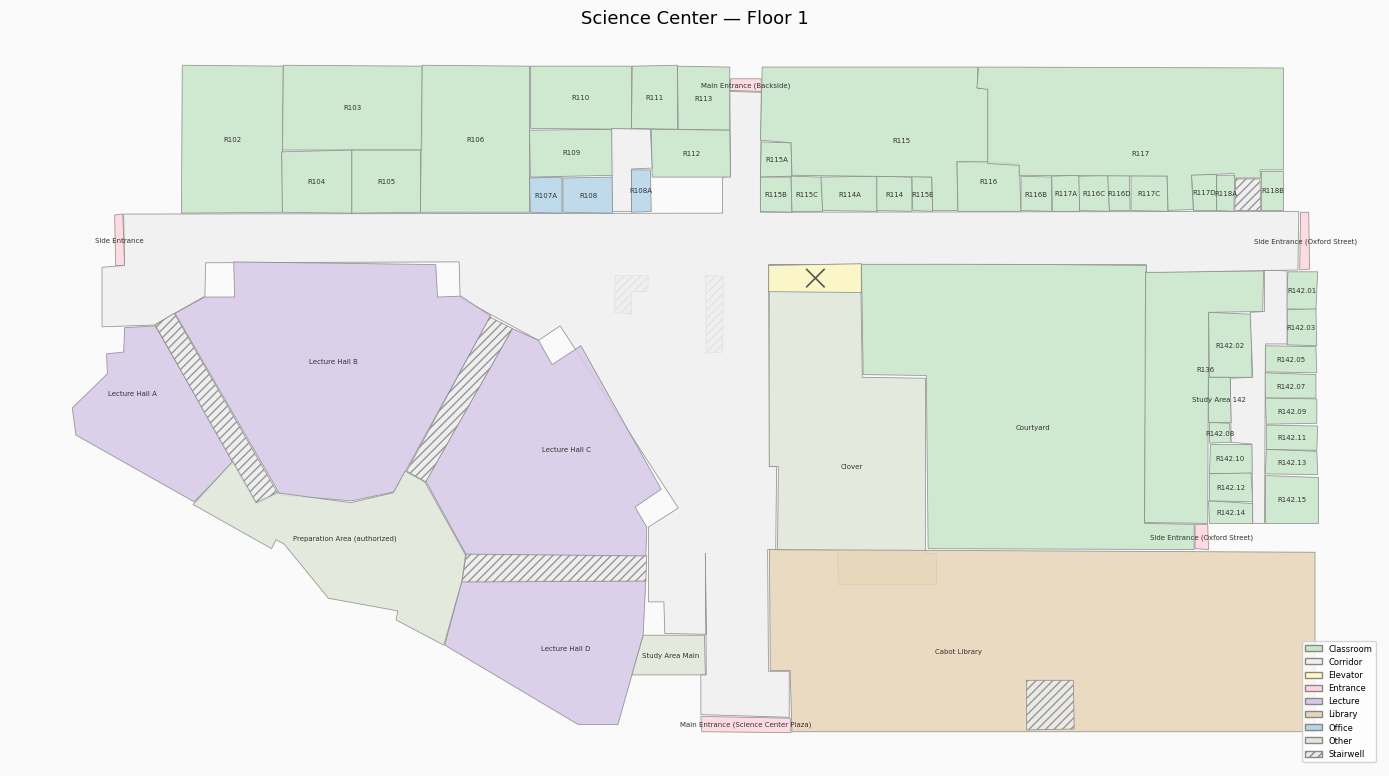

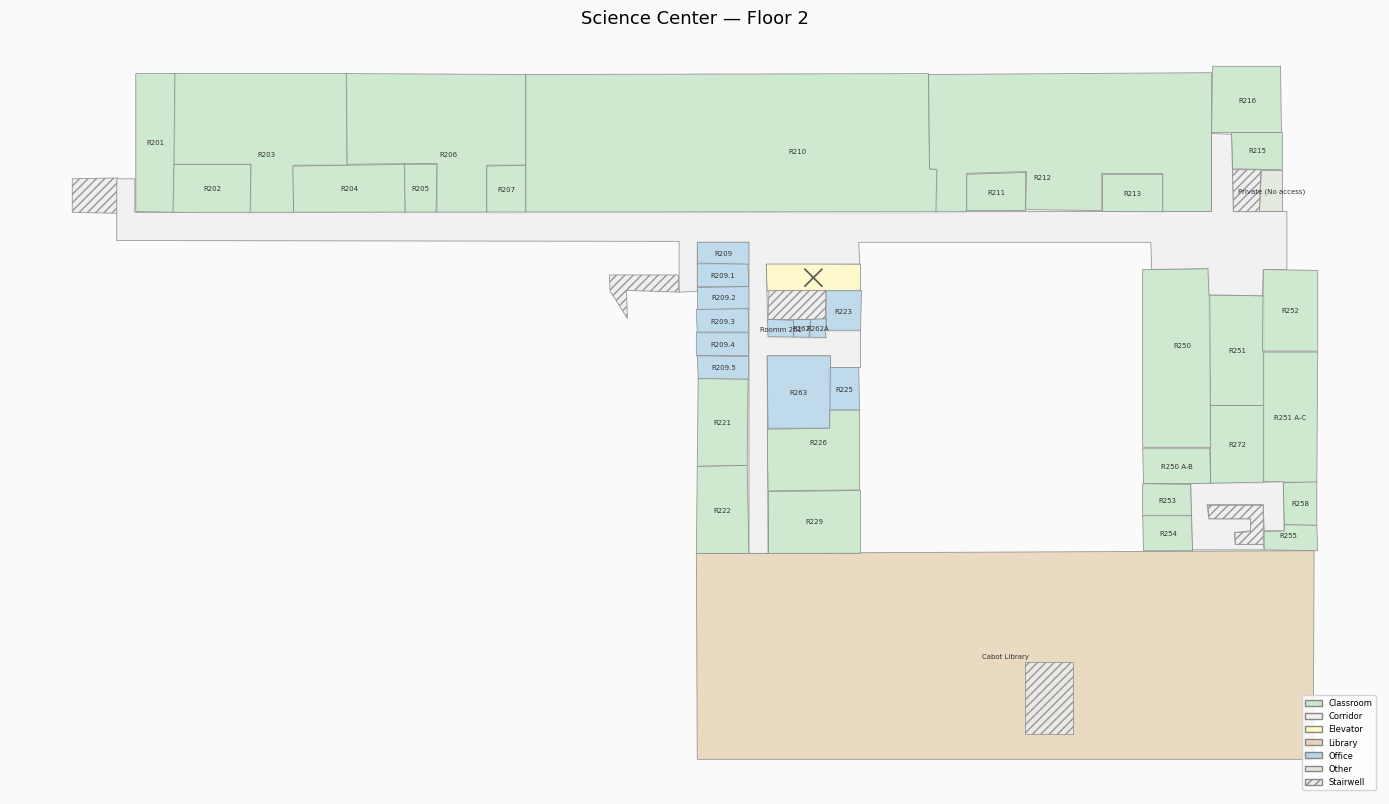

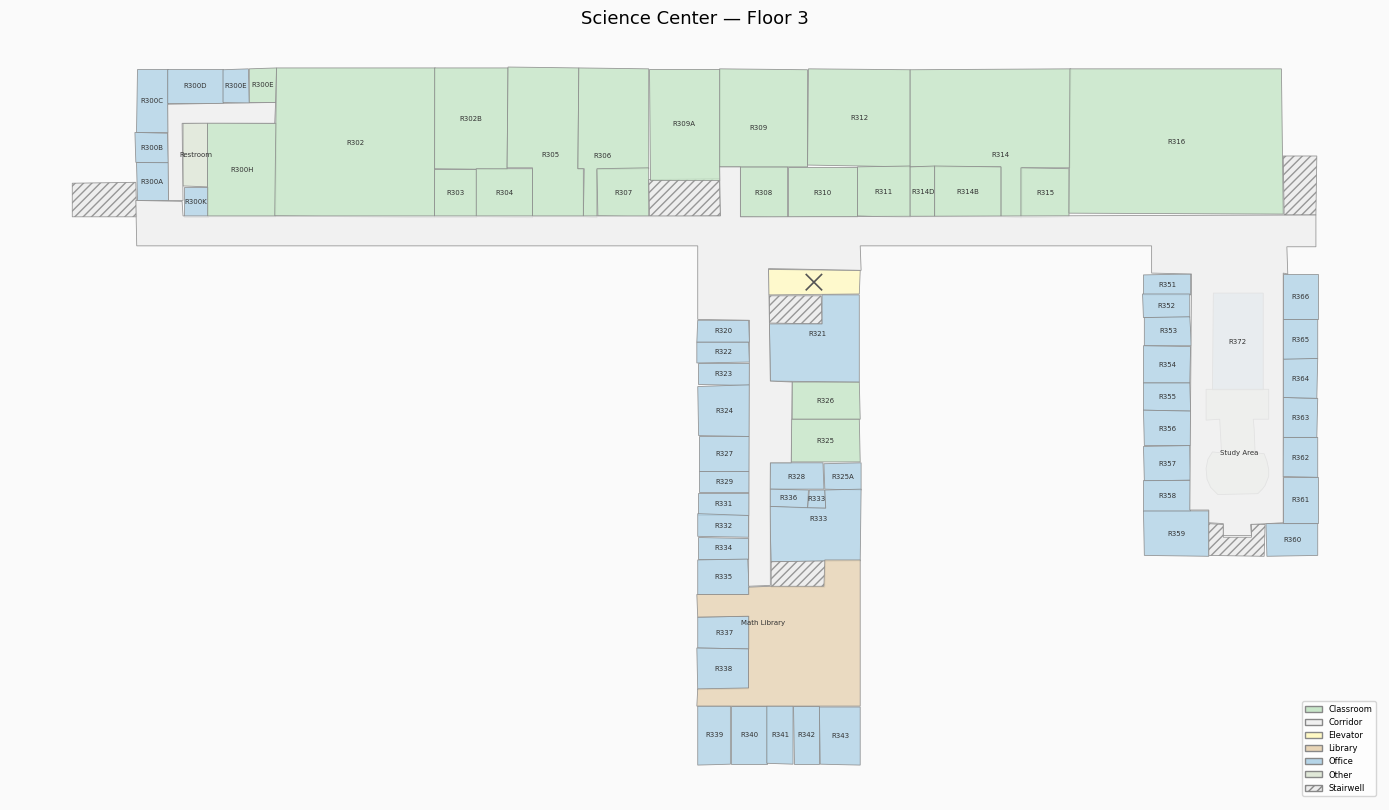

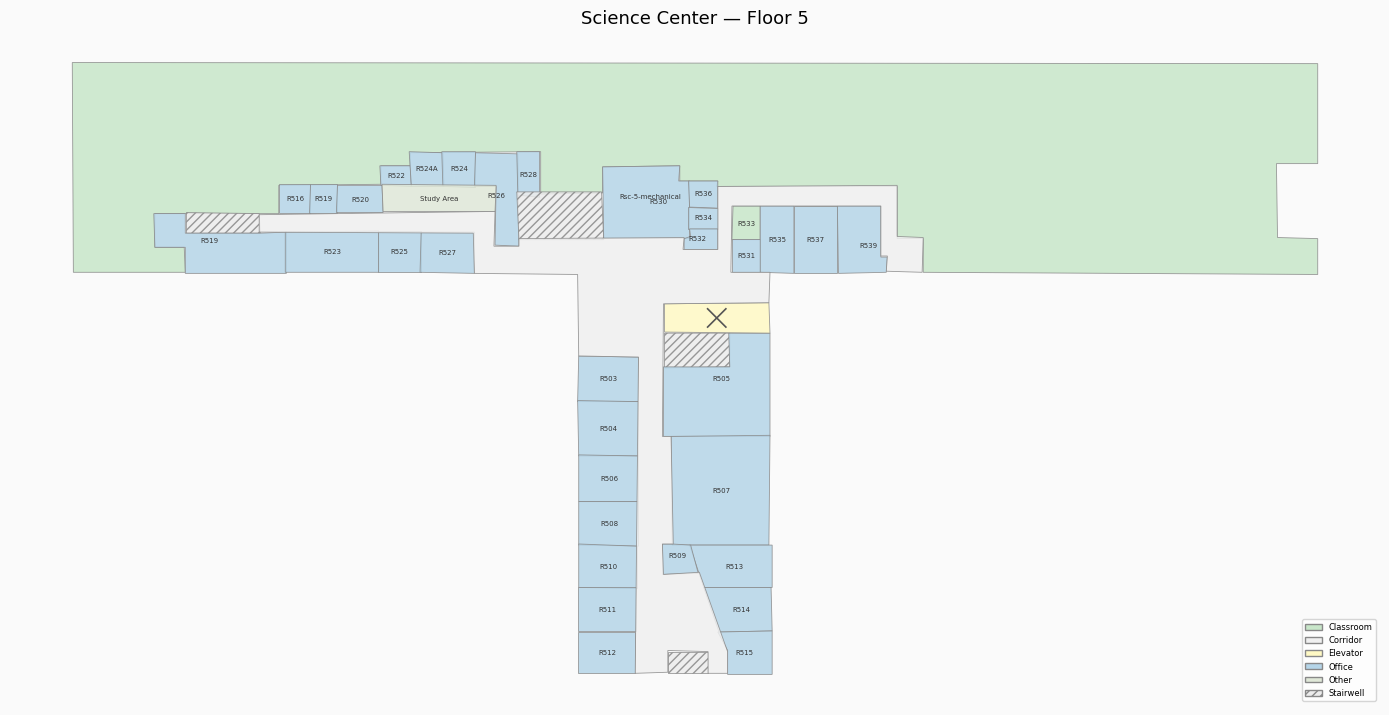

In [18]:
# Render each floor individually using all_floors loaded in Section 1
for key, data in all_floors.items():
    draw_floor(data, f'Science Center — Floor {key}')
